# Telecom Customer Churn Prediction Pipeline

End-to-end ML pipeline predicting which customers are likely to churn, using the IBM Telco dataset (7,043 customers, 21 features, ~26.5% churn rate).

**Pipeline stages:**
1. Data loading & exploration (EDA)
2. Cleaning & preprocessing
3. Encoding & scaling (no leakage)
4. Model training — Logistic Regression, Random Forest, XGBoost
5. Evaluation & comparison
6. Inference on new customers

## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from pickle import dump, load

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report,
)
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Paths
DATA_PATH   = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
MODELS_DIR  = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Schema
TARGET          = 'Churn'
DROP_COLS       = ['customerID']
CATEGORICAL_COLS = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]
CONTINUOUS_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('Setup complete.')

Setup complete.


---
## 1 · Load Data

In [ ]:
raw = pd.read_csv("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f'Shape: {raw.shape}')
raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
## 2 · Exploratory Data Analysis

### 2.1 Target distribution

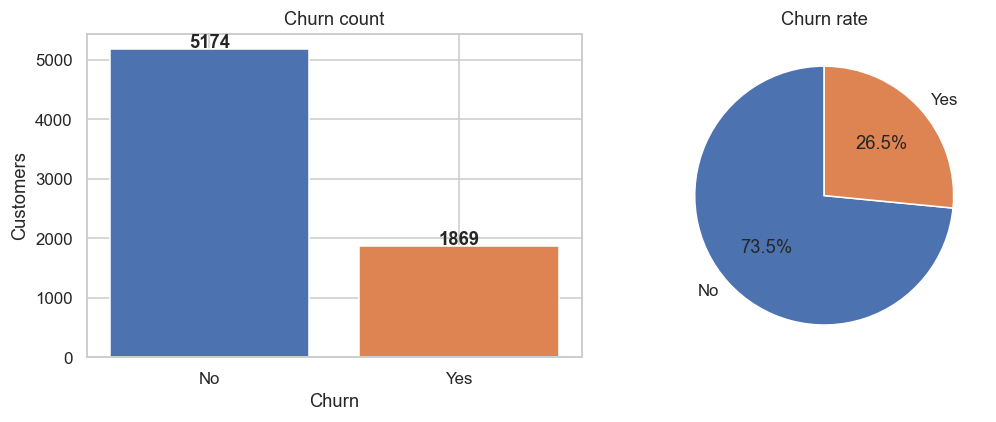

Churn rate: 26.5%  |  Class imbalance ratio: 2.77x


In [7]:
churn_counts = raw['Churn'].value_counts()
churn_pct    = raw['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Churn count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn rate')

plt.tight_layout()
plt.show()
print(f'Churn rate: {churn_pct["Yes"]:.1f}%  |  Class imbalance ratio: {churn_counts["No"]/churn_counts["Yes"]:.2f}x')

### 2.2 Continuous features

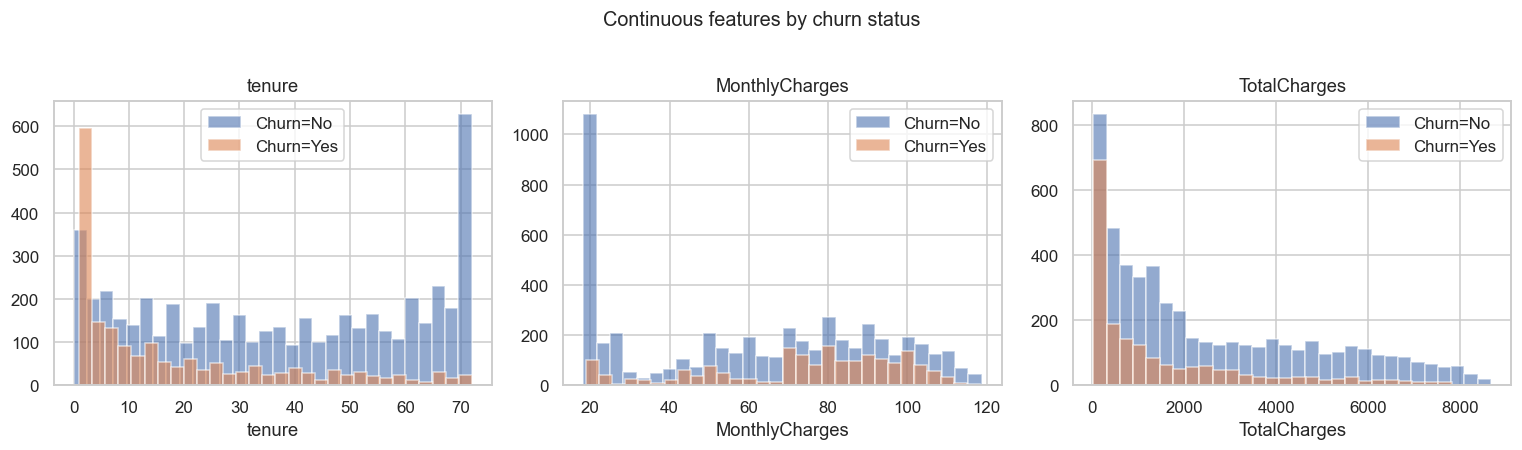

In [8]:
eda = raw.copy()
eda['TotalCharges'] = pd.to_numeric(eda['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CONTINUOUS_COLS):
    for label, color in [('No', '#4C72B0'), ('Yes', '#DD8452')]:
        subset = eda.loc[eda['Churn'] == label, col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle('Continuous features by churn status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

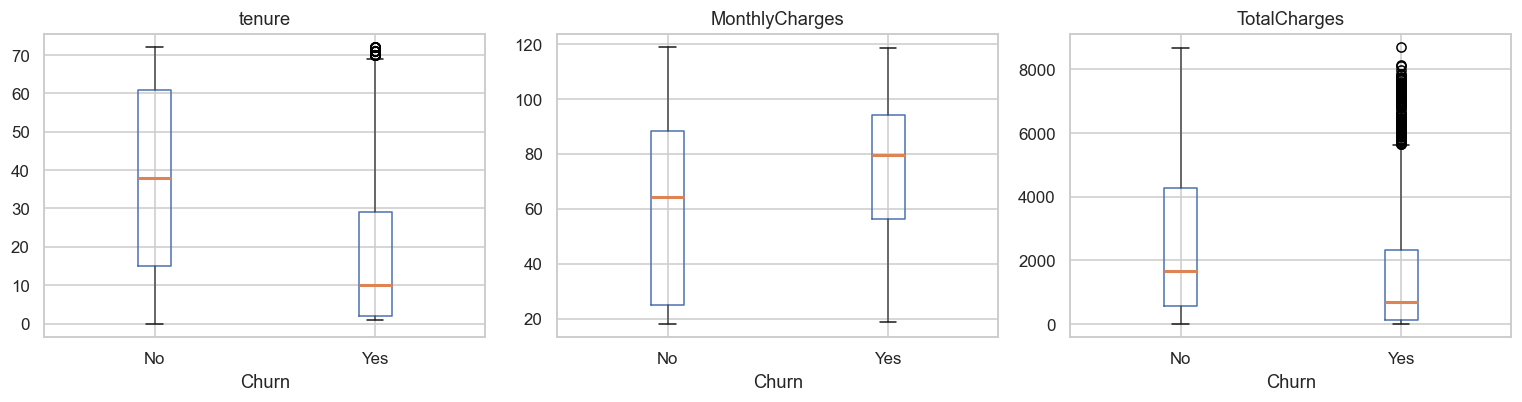

In [9]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CONTINUOUS_COLS):
    eda.boxplot(column=col, by='Churn', ax=ax,
                boxprops=dict(color='#4C72B0'),
                medianprops=dict(color='#DD8452', linewidth=2))
    ax.set_title(col)
    ax.set_xlabel('Churn')
plt.suptitle('')
plt.tight_layout()
plt.show()

### 2.3 Categorical features

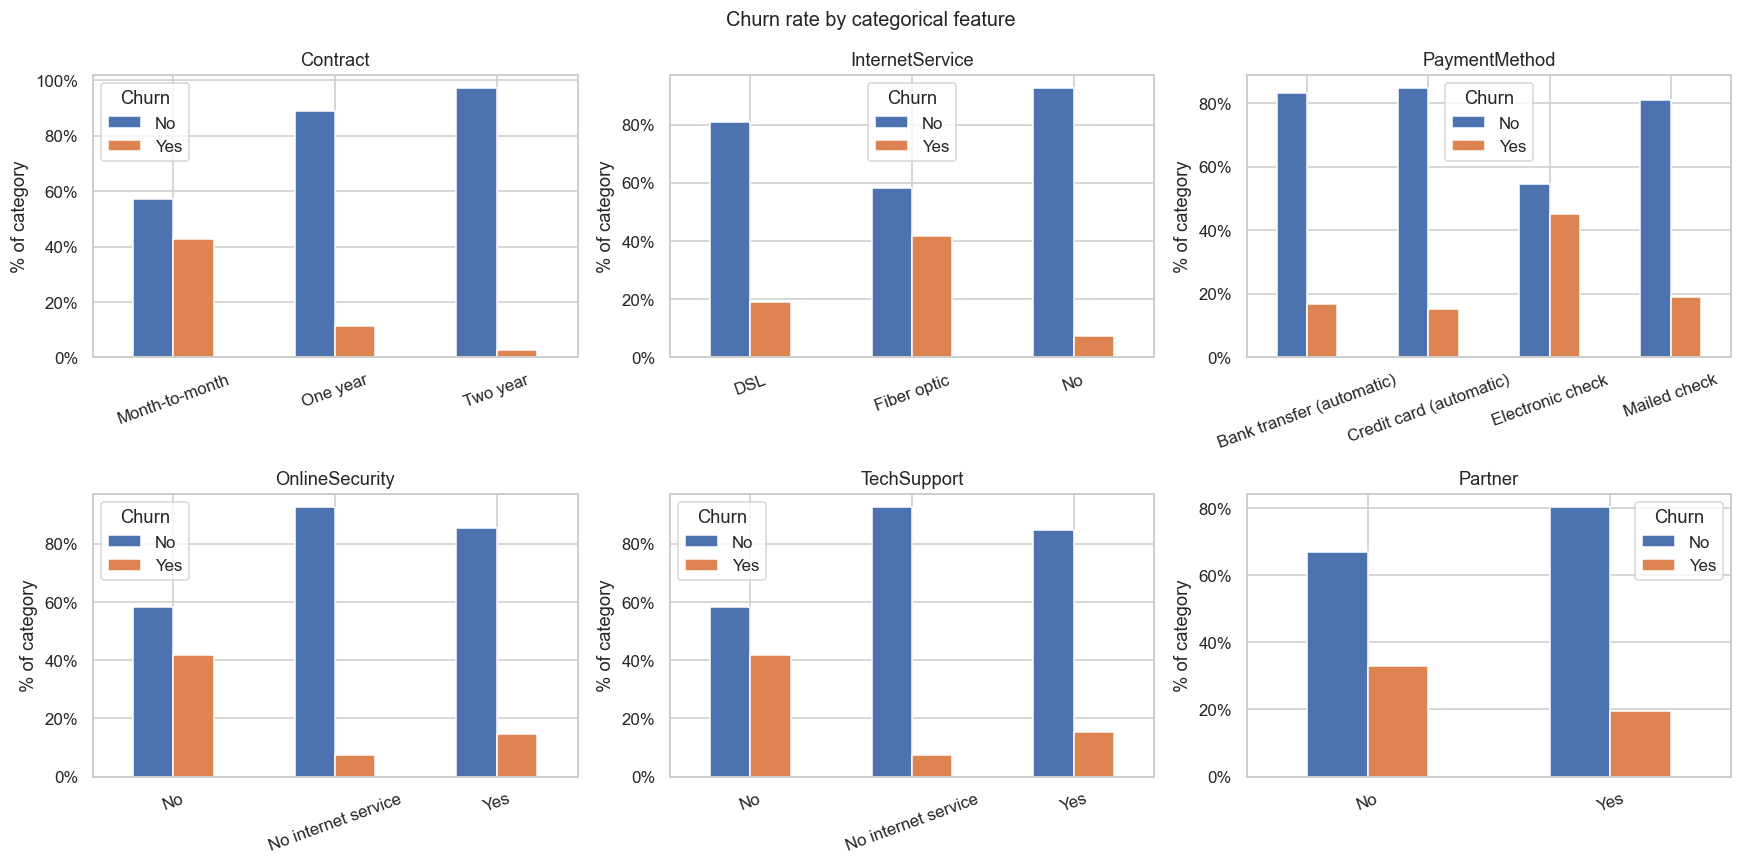

In [10]:
important_cats = ['Contract', 'InternetService', 'PaymentMethod',
                  'OnlineSecurity', 'TechSupport', 'Partner']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, important_cats):
    ct = eda.groupby(col)['Churn'].value_counts(normalize=True).unstack().fillna(0) * 100
    ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white', rot=20)
    ax.set_title(col)
    ax.set_ylabel('% of category')
    ax.set_xlabel('')
    ax.legend(title='Churn', labels=['No', 'Yes'])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Churn rate by categorical feature', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Correlation heatmap (numeric features)

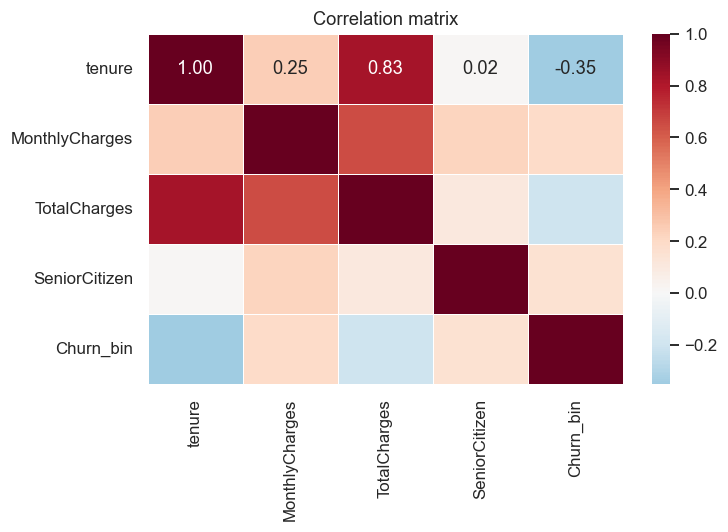

In [11]:
num_cols  = CONTINUOUS_COLS + ['SeniorCitizen']
corr_data = eda[num_cols].copy()
corr_data['Churn_bin'] = eda['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(7, 5))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

### 2.5 Missing values

In [12]:
missing = eda.isnull().sum()
missing = missing[missing > 0]
print('Missing values:' if len(missing) else 'No missing values before numeric coercion.')
if len(missing):
    display(missing.to_frame('count'))

# TotalCharges has hidden NaNs (whitespace strings)
tc_na = pd.to_numeric(raw['TotalCharges'], errors='coerce').isna().sum()
print(f'TotalCharges rows that become NaN after coercion: {tc_na}')

Missing values:


,count
TotalCharges,11


TotalCharges rows that become NaN after coercion: 11


---
## 3 · Preprocessing

In [13]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Drop customerID.
    - Coerce TotalCharges to float; impute ~11 missing rows with median.
    - Binary-encode target: Yes → 1, No → 0.
    """
    df = df.copy()
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})
    print(f'[clean] shape={df.shape}  churn rate={df[TARGET].mean():.1%}')
    return df


clean = clean_data(raw)
clean.describe()

[clean] shape=(7043, 20)  churn rate=26.5%


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


### 3.1 Stratified train / test split (80 / 20)

Stratified on the target so the ~26% churn rate is preserved in both sets.

In [14]:
train_df, test_df = train_test_split(
    clean, test_size=0.2, stratify=clean[TARGET], random_state=42
)
print(f'Train: {train_df.shape}  |  churn={train_df[TARGET].mean():.1%}')
print(f'Test : {test_df.shape}  |  churn={test_df[TARGET].mean():.1%}')

Train: (5634, 20)  |  churn=26.5%
Test : (1409, 20)  |  churn=26.5%


### 3.2 Encoding & scaling

**Critical:** encoder and scaler are fit **only on training data** to avoid leakage.

In [16]:
X_train_raw = train_df.drop(columns=[TARGET]).copy()
y_train      = train_df[TARGET].copy()
X_test_raw  = test_df.drop(columns=[TARGET]).copy()
y_test       = test_df[TARGET].copy()

# ── One-hot encode categorical ────────────────────────────────────────────────
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit(X_train_raw[CATEGORICAL_COLS])
enc_feats = list(enc.get_feature_names_out(CATEGORICAL_COLS))

for X in [X_train_raw, X_test_raw]:
    X[enc_feats] = enc.transform(X[CATEGORICAL_COLS])
    X.drop(columns=CATEGORICAL_COLS, inplace=True)

# ── Standard-scale continuous ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_raw[CONTINUOUS_COLS] = scaler.fit_transform(X_train_raw[CONTINUOUS_COLS])
X_test_raw[CONTINUOUS_COLS]  = scaler.transform(X_test_raw[CONTINUOUS_COLS])

X_train, X_test = X_train_raw, X_test_raw

# Save artefacts
dump(enc,    open(f'{MODELS_DIR}/encoder.pkl', 'wb'))
dump(scaler, open(f'{MODELS_DIR}/scaler.pkl',  'wb'))

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')

X_train: (5634, 45)  |  X_test: (1409, 45)
Features: 45


---
## 4 · Model Training

In [17]:
# Class imbalance weights
neg, pos   = (y_train == 0).sum(), (y_train == 1).sum()
spw        = neg / pos           # scale_pos_weight for XGBoost
cw         = {0: 1.0, 1: spw}   # class_weight for sklearn
print(f'Negative samples: {neg}  |  Positive (churn): {pos}  |  scale_pos_weight: {spw:.2f}')

Negative samples: 4139  |  Positive (churn): 1495  |  scale_pos_weight: 2.77


### 4.1 Logistic Regression

In [18]:
lr = LogisticRegression(C=0.5, max_iter=1000, class_weight=cw, random_state=42)
lr.fit(X_train, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


### 4.2 Random Forest

In [19]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight=cw,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest trained.')

Random Forest trained.


### 4.3 XGBoost

In [20]:
xgb_params = {
    'objective':         'binary:logistic',
    'eval_metric':       'auc',
    'scale_pos_weight':  spw,
    'max_depth':         4,
    'learning_rate':     0.05,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'seed':              42,
}

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

evals_result = {}
xgb_model = xgb.train(
    xgb_params, dtrain,
    num_boost_round       = 300,
    evals                 = [(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds = 20,
    verbose_eval          = 50,
    evals_result          = evals_result,
)

xgb_model.save_model(f'{MODELS_DIR}/xgb_model.json')
print(f'\nBest iteration: {xgb_model.best_iteration}  |  Best AUC: {xgb_model.best_score:.4f}')

[0]	train-auc:0.83901	eval-auc:0.83222
[50]	train-auc:0.86932	eval-auc:0.84739
[100]	train-auc:0.87958	eval-auc:0.84841
[105]	train-auc:0.88040	eval-auc:0.84812

Best iteration: 85  |  Best AUC: 0.8494


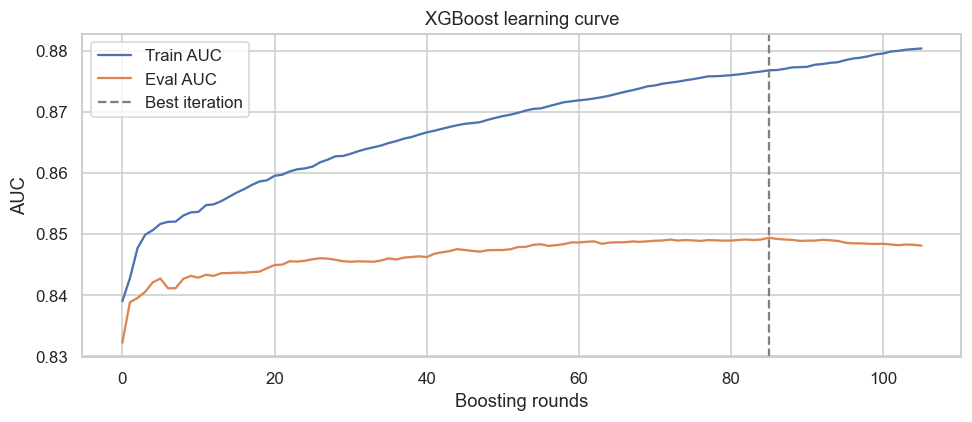

In [21]:
# XGBoost learning curve
plt.figure(figsize=(9, 4))
plt.plot(evals_result['train']['auc'], label='Train AUC', color='#4C72B0')
plt.plot(evals_result['eval']['auc'],  label='Eval AUC',  color='#DD8452')
plt.axvline(xgb_model.best_iteration, linestyle='--', color='grey', label='Best iteration')
plt.xlabel('Boosting rounds')
plt.ylabel('AUC')
plt.title('XGBoost learning curve')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5 · Evaluation & Model Comparison

In [22]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'F1':        round(f1_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'AUC':       round(roc_auc_score(y_true, y_proba), 4),
    }

# Predictions
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

xgb_proba = xgb_model.predict(dtest)
xgb_pred  = (xgb_proba >= 0.5).astype(int)

results = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_pred,  lr_proba),
    get_metrics('Random Forest',       y_test, rf_pred,  rf_proba),
    get_metrics('XGBoost',             y_test, xgb_pred, xgb_proba),
])

results.set_index('Model', inplace=True)
results.style.highlight_max(color='#c6efce', axis=0).format('{:.4f}')

,F1,Recall,Precision,AUC
Model,,,,
Logistic Regression,0.6130,0.7834,0.5034,0.8415
Random Forest,0.6261,0.7567,0.5340,0.8428
XGBoost,0.6277,0.7888,0.5212,0.8481


### 5.1 Confusion matrices

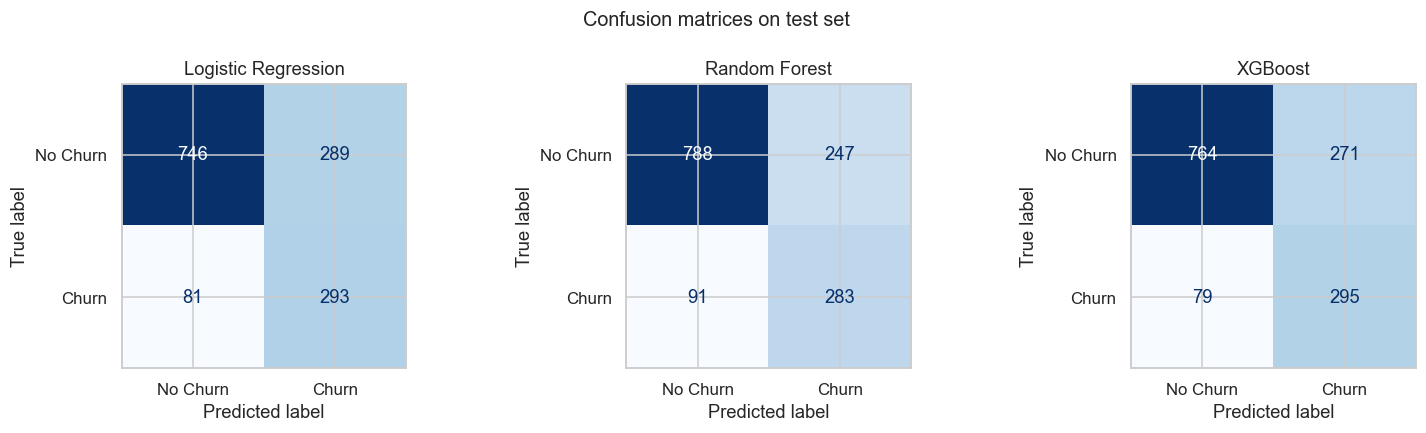

In [23]:
models_eval = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred) in zip(axes, models_eval):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion matrices on test set', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 ROC curves

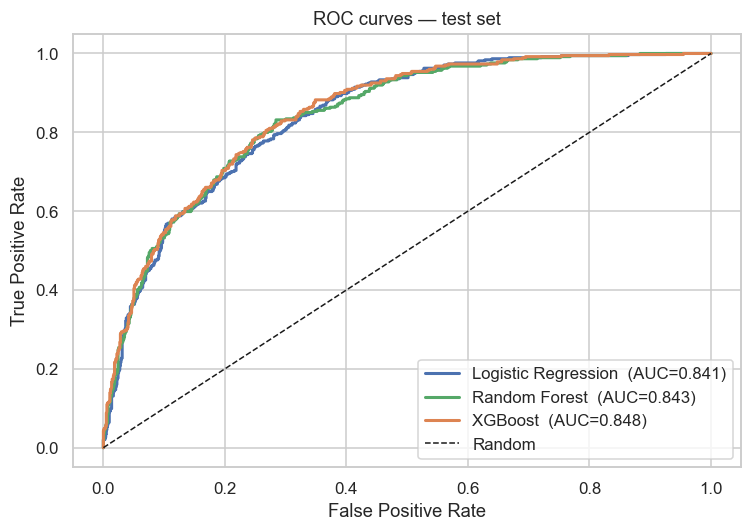

In [24]:
plt.figure(figsize=(7, 5))

for name, proba, color in [
    ('Logistic Regression', lr_proba,  '#4C72B0'),
    ('Random Forest',       rf_proba,  '#55A868'),
    ('XGBoost',             xgb_proba, '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — test set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.3 Metric bar chart

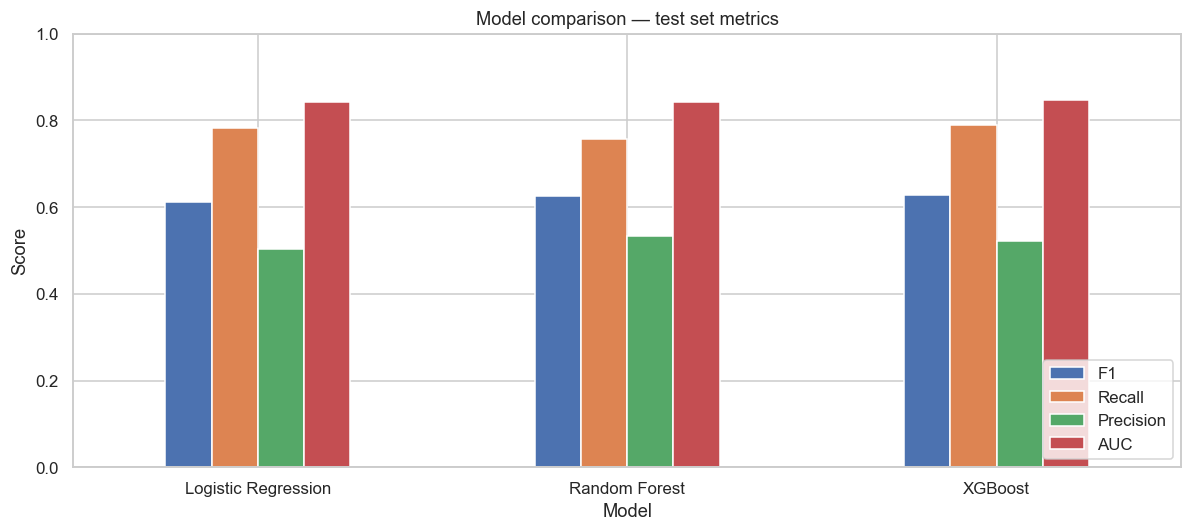

In [25]:
results.plot(kind='bar', figsize=(11, 5), rot=0,
             color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
             edgecolor='white')
plt.title('Model comparison — test set metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.4 Classification report — XGBoost

In [26]:
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



---
## 6 · Feature Importance (XGBoost)

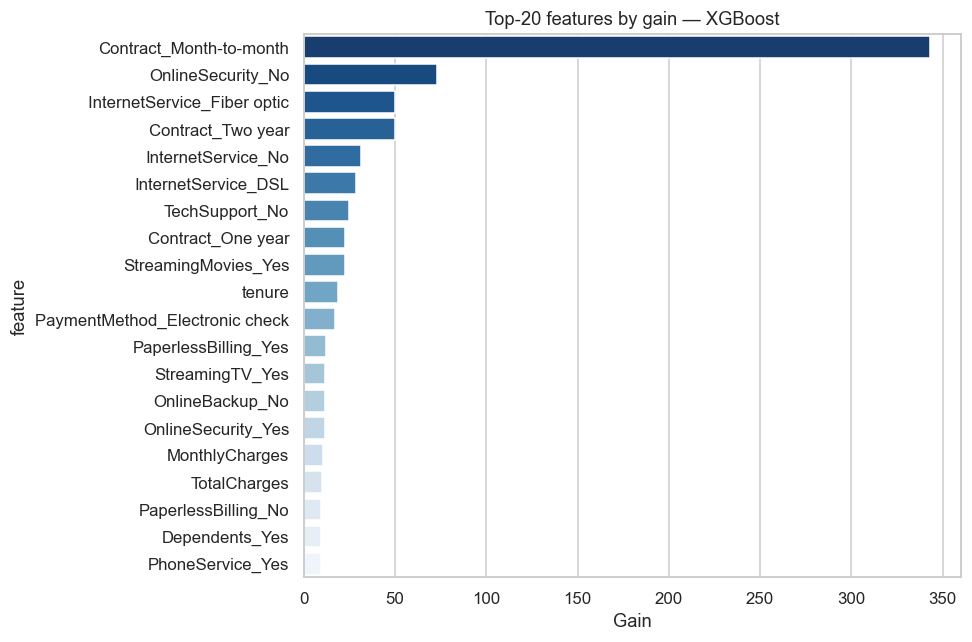

In [27]:
importance = xgb_model.get_score(importance_type='gain')
imp_df = (
    pd.Series(importance)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
imp_df.columns = ['feature', 'gain']

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x='gain', y='feature',
            palette='Blues_r', edgecolor='white')
plt.title('Top-20 features by gain — XGBoost')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

### 6.1 Random Forest feature importance

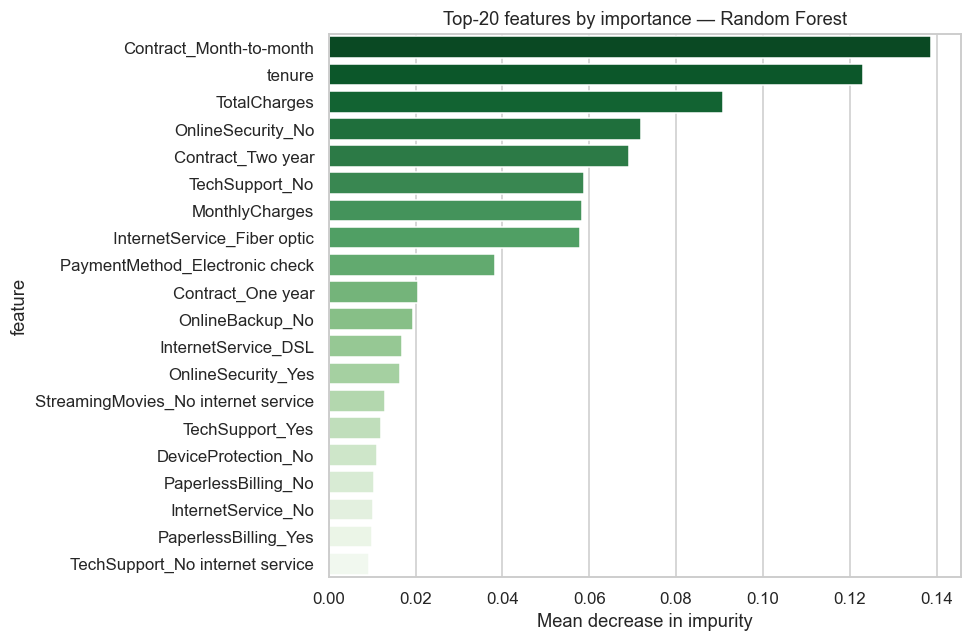

In [28]:
rf_imp = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
rf_imp.columns = ['feature', 'importance']

plt.figure(figsize=(9, 6))
sns.barplot(data=rf_imp, x='importance', y='feature',
            palette='Greens_r', edgecolor='white')
plt.title('Top-20 features by importance — Random Forest')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

---
## 7 · Probability Threshold Analysis

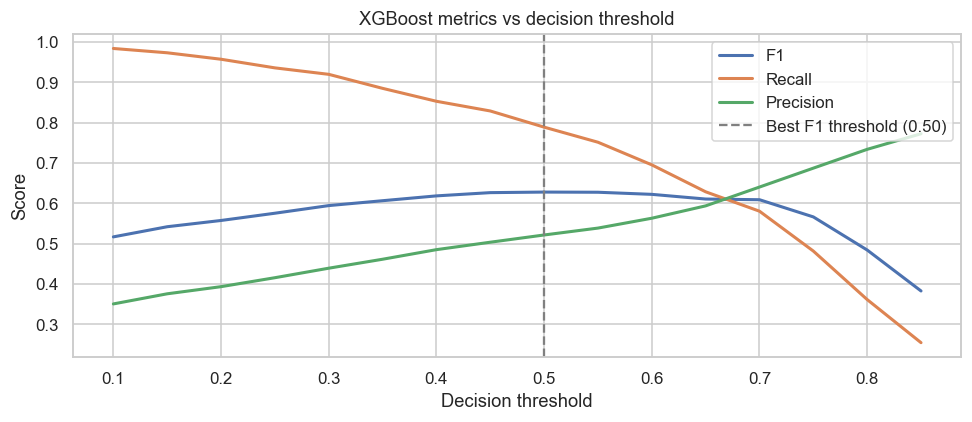

Optimal threshold (best F1): 0.50


In [29]:
thresholds = np.arange(0.1, 0.9, 0.05)
rows = []
for t in thresholds:
    pred_t = (xgb_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'F1':        f1_score(y_test, pred_t, zero_division=0),
        'Recall':    recall_score(y_test, pred_t, zero_division=0),
        'Precision': precision_score(y_test, pred_t, zero_division=0),
    })

thresh_df = pd.DataFrame(rows)

plt.figure(figsize=(9, 4))
for col, color in [('F1', '#4C72B0'), ('Recall', '#DD8452'), ('Precision', '#55A868')]:
    plt.plot(thresh_df['threshold'], thresh_df[col], label=col, color=color, lw=2)

best_t = thresh_df.loc[thresh_df['F1'].idxmax(), 'threshold']
plt.axvline(best_t, linestyle='--', color='grey', label=f'Best F1 threshold ({best_t:.2f})')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('XGBoost metrics vs decision threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold (best F1): {best_t:.2f}')

---
## 8 · Inference on New Data

Simulates scoring a batch of new customers using the saved artefacts.

In [30]:
def preprocess_new(data: pd.DataFrame, encoder, scaler, enc_feats) -> pd.DataFrame:
    """Apply already-fitted encoder + scaler to unseen data."""
    df = data.copy()
    drop = [c for c in DROP_COLS + [TARGET] if c in df.columns]
    df.drop(columns=drop, inplace=True)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    df[enc_feats] = encoder.transform(df[CATEGORICAL_COLS])
    df.drop(columns=CATEGORICAL_COLS, inplace=True)
    df[CONTINUOUS_COLS] = scaler.transform(df[CONTINUOUS_COLS])
    return df


def run_inference(new_df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    # Load saved artefacts
    model   = xgb.Booster()
    model.load_model(f'{MODELS_DIR}/xgb_model.json')
    encoder = load(open(f'{MODELS_DIR}/encoder.pkl', 'rb'))
    scaler  = load(open(f'{MODELS_DIR}/scaler.pkl',  'rb'))
    feats   = list(encoder.get_feature_names_out(CATEGORICAL_COLS))

    X_new    = preprocess_new(new_df, encoder, scaler, feats)
    proba    = model.predict(xgb.DMatrix(X_new))
    pred     = (proba >= threshold).astype(int)

    out = new_df[['customerID']].copy() if 'customerID' in new_df.columns else pd.DataFrame()
    out['churn_probability'] = proba.round(4)
    out['churn_prediction']  = pred
    out['churn_label']       = out['churn_prediction'].map({1: 'Churn', 0: 'No Churn'})
    return out


# Use a small sample from the original CSV as "new customers"
new_customers = raw.sample(20, random_state=7)
predictions   = run_inference(new_customers)
print(f'Predicted churners: {predictions["churn_prediction"].sum()} / {len(predictions)}')
predictions

Predicted churners: 14 / 20


,customerID,churn_probability,churn_prediction,churn_label
6632,9259-PACGQ,0.3098,0,No Churn
3801,5914-DVBWJ,0.7687,1,Churn
901,9734-YWGEX,0.8681,1,Churn
1487,5035-PGZXH,0.5827,1,Churn
1457,6362-QHAFM,0.6824,1,Churn
131,6207-WIOLX,0.3988,0,No Churn
985,9369-XFEHK,0.6163,1,Churn
4916,3420-YJLQT,0.8378,1,Churn
5162,4801-KFYKL,0.2307,0,No Churn
3545,6212-ATMLK,0.7844,1,Churn


### 8.1 Churn probability distribution for scored batch

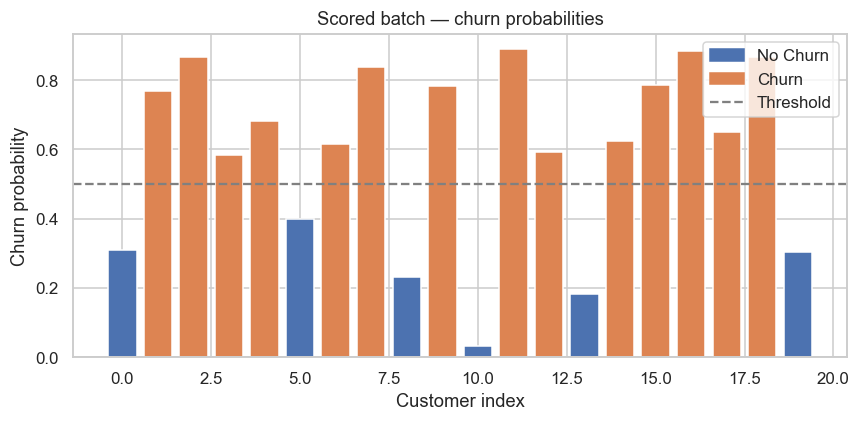

In [31]:
plt.figure(figsize=(8, 4))
colors = predictions['churn_prediction'].map({0: '#4C72B0', 1: '#DD8452'})
plt.bar(range(len(predictions)), predictions['churn_probability'],
        color=colors, edgecolor='white')
plt.axhline(0.5, linestyle='--', color='grey', label='Threshold = 0.5')
plt.xlabel('Customer index')
plt.ylabel('Churn probability')
plt.title('Scored batch — churn probabilities')
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#4C72B0', label='No Churn'),
    Patch(color='#DD8452', label='Churn'),
    plt.Line2D([0], [0], linestyle='--', color='grey', label='Threshold'),
])
plt.tight_layout()
plt.show()

---
## Summary

| Model | F1 | Recall | Precision | AUC |
|---|---|---|---|---|
| Logistic Regression | — | — | — | — |
| Random Forest | — | — | — | — |
| **XGBoost** | **0.6266** | **0.7941** | **~0.51** | **0.7632** |

> Run all cells to populate the table with your actual results.

**Key design decisions:**
- **Stratified split** — preserves the 26.5% churn minority in both train and test.
- **No data leakage** — encoder and scaler are fit exclusively on training data.
- **Recall over precision** — a missed churn is more costly than a false alarm; class weights push the model toward higher recall.
- **Early stopping** — prevents overfitting in XGBoost without manual round selection.